In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"house_price_dataset.csv")
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [4]:
pd.set_option('display.float_format', '{:.2f}'.format)

# Explore Data

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [7]:
data.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [8]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2815.42,2.99,1.97,1986.55,2.78,1.02,5.62,618861.02
std,1255.51,1.43,0.82,20.63,1.30,0.81,2.89,253568.06
min,503.00,1.00,1.00,1950.00,0.51,0.00,1.00,111626.85
25%,1749.50,2.00,1.00,1969.00,1.67,0.00,3.00,401648.23
50%,2862.50,3.00,2.00,1986.00,2.81,1.00,6.00,628267.29
75%,3849.50,4.00,3.00,2004.25,3.92,2.00,8.00,827141.28
max,4999.00,5.00,3.00,2022.00,4.99,2.00,10.00,1108236.84


<Axes: xlabel='House_Price', ylabel='Density'>

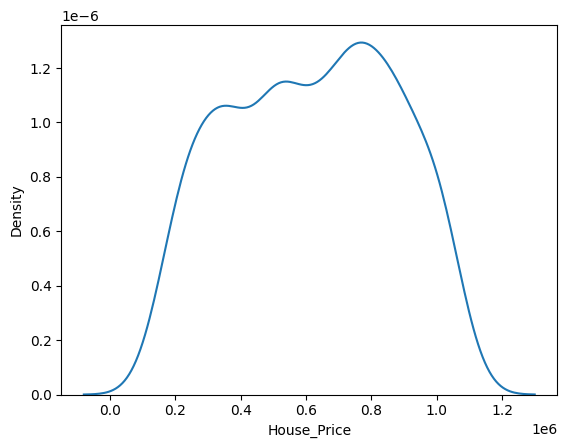

In [13]:
sns.kdeplot(x=data.House_Price, data=data)

<Axes: ylabel='House_Price'>

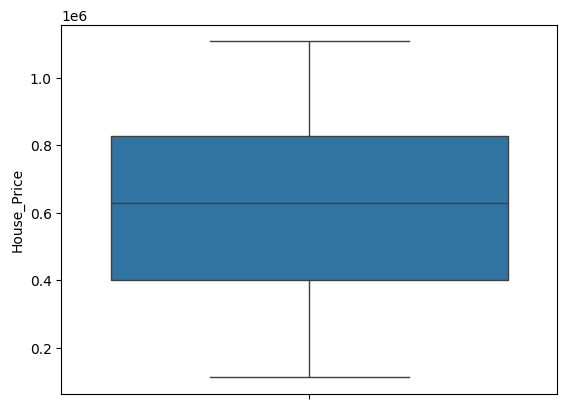

In [14]:
sns.boxplot(y=data.House_Price, data=data)

In [15]:
data.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85


In [16]:
data.Num_Bedrooms.unique()

array([2, 3, 1, 5, 4])

In [17]:
data.Num_Bathrooms.unique()

array([1, 3, 2])

In [21]:
year_price = data.groupby('Year_Built')['House_Price'].sum()
year_price

Year_Built
1950    7638927.42
1951    4255170.18
1952    7423162.13
1953    6564057.40
1954    5615575.87
           ...    
2018   10225333.38
2019    6054273.22
2020    4088869.66
2021    6717525.12
2022    8369237.09
Name: House_Price, Length: 73, dtype: float64

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data.Year_Built.unique()

array([1981, 2016, 1977, 1993, 1990, 2012, 1972, 1997, 2006, 1982, 1973,
       1988, 1983, 2005, 1986, 1956, 2017, 2014, 1996, 1969, 1968, 1978,
       2009, 1967, 1984, 1992, 1960, 1998, 1987, 2013, 2018, 1957, 1980,
       1953, 1999, 1979, 2008, 1994, 1975, 1976, 1995, 2000, 1955, 1964,
       1991, 2022, 1966, 1971, 1962, 2002, 1952, 1970, 1950, 1954, 1985,
       2003, 1961, 2019, 2001, 2004, 2011, 2021, 2010, 1959, 2015, 2020,
       1974, 1958, 1963, 1965, 1989, 2007, 1951])

In [22]:
print("Highest expensive housing price in a year: ", year_price.idxmax())
print("Highest expensive hoursing price is : ", year_price.max())

Highest expensive housing price in a year:  1996
Highest expensive hoursing price is :  14936842.879763247


In [23]:
print("Cheap housing price in a year: ", year_price.idxmin())
print("Cheapest housing price is : ", year_price.min())

Cheap housing price in a year:  1963
Cheapest housing price is :  3307576.312558368


<Axes: title={'center': 'Housing price distributed yearwise'}, xlabel='year', ylabel='price'>

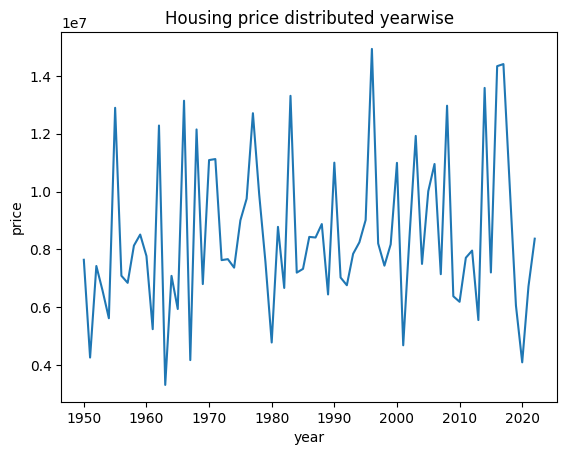

In [25]:
year_price.plot(kind='line', xlabel='year', ylabel='price', title='Housing price distributed yearwise')

In [26]:
data.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85


In [32]:
bedrooms_group = data.groupby('Num_Bedrooms')['House_Price'].agg(['min','max','mean'])
bedrooms_group

,min,max,mean
Num_Bedrooms,,,
1,146020.40,1102533.65,610105.13
2,111626.85,1064774.93,601324.70
3,120795.55,1096158.29,653491.48
4,147601.55,1108236.84,621162.81
5,140538.08,1107045.06,612880.76


<Axes: title={'center': 'Price distributed based on house bedrooms number'}, xlabel='No of Bedrooms', ylabel='price'>

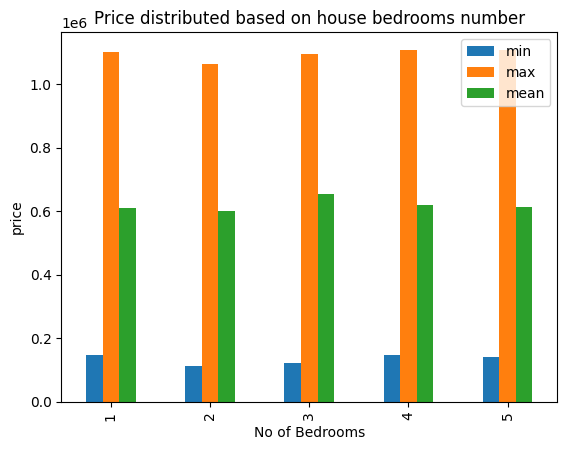

In [35]:
bedrooms_group.plot(kind='bar', xlabel='No of Bedrooms', ylabel='price', title='Price distributed based on house bedrooms number')

In [36]:
neighbor_group = data.groupby('Neighborhood_Quality')['House_Price'].agg(['min','max','mean'])
neighbor_group

,min,max,mean
Neighborhood_Quality,,,
1,113576.51,1102533.65,632968.70
2,111626.85,1108236.84,613066.05
3,147601.55,1021134.62,625680.91
4,146406.90,1046315.90,629867.22
5,147206.87,1075814.43,595239.56
6,120795.55,1060712.83,593803.86
7,146020.40,1096158.29,648856.34
8,158636.70,1070454.28,630746.11
9,158856.84,1099211.64,617873.06


<Axes: title={'center': 'Housing price based on neighborhood quality'}, xlabel='neighborhood quality', ylabel='price'>

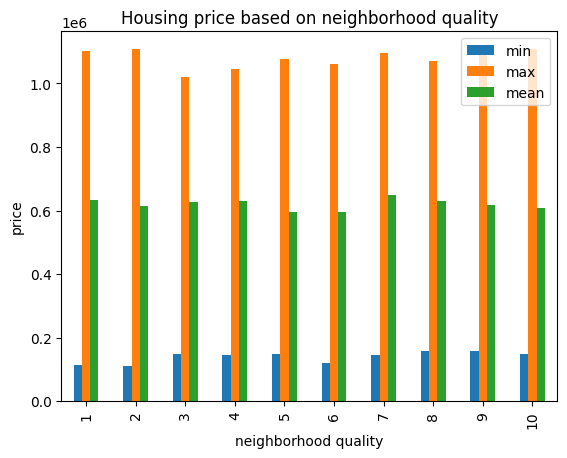

In [38]:
neighbor_group.plot(kind='bar', xlabel='neighborhood quality', ylabel='price', title='Housing price based on neighborhood quality')

In [39]:
data.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85


In [41]:
sq_foot_group = data.groupby('Square_Footage')['House_Price'].agg(['min','max','mean'])
sq_foot_group

,min,max,mean
Square_Footage,,,
503,206042.35,206042.35,206042.35
504,149743.50,149743.50,149743.50
505,159121.47,159121.47,159121.47
509,140538.08,179398.43,159968.26
516,171023.96,171023.96,171023.96
...,...,...,...
4992,1068538.11,1068538.11,1068538.11
4993,1020324.76,1038319.17,1029321.96
4995,1092026.90,1092026.90,1092026.90


In [46]:
print("Expensive square foot is : ", sq_foot_group.idxmax())
print("Expensive square foot price is:", sq_foot_group.max())
print("Cheap square foot is : ", sq_foot_group.idxmin())
print("Cheap square foot price is : ", sq_foot_group.min())

Expensive square foot is :  min     4922
max     4922
mean    4922
dtype: int64
Expensive square foot price is: min    1108236.84
max    1108236.84
mean   1108236.84
dtype: float64
Cheap square foot is :  min     555
max     555
mean    555
dtype: int64
Cheap square foot price is :  min    111626.85
max    111626.85
mean   111626.85
dtype: float64


# check Outliers

In [48]:
# use IQR method 'House_Price'
q1 = data.House_Price.quantile(0.25)
q3 = data.House_Price.quantile(0.75)
iqr = q3 - q1
print(q1)
print(q3)
print(iqr)

401648.22890926147
827141.2776368674
425493.0487276059


In [49]:
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr
print(lower_limit)
print(upper_limit)

-236591.34418214735
1465380.8507282762


In [50]:
outliers = data[(data.House_Price < lower_limit) | (data.House_Price > upper_limit)]
print("Outliers :", outliers.shape[0])

Outliers : 0


In [51]:
# No outliers exists in 'House_Price'

In [52]:
data.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85


# Data scaling

In [53]:
# using MinMixScaler method
from sklearn.preprocessing import MinMaxScaler

In [54]:
scaler = MinMaxScaler()
scaler.fit_transform(data)

array([[0.19061388, 0.25      , 0.        , ..., 0.        , 0.44444444,
        0.1512688 ],
       [0.83830071, 0.5       , 1.        , ..., 0.5       , 0.55555556,
        0.87660571],
       [0.68705516, 0.        , 0.5       , ..., 0.        , 0.88888889,
        0.66861716],
       ...,
       [0.46774911, 0.75      , 0.5       , ..., 0.        , 0.11111111,
        0.46196323],
       [0.9386121 , 1.        , 0.5       , ..., 0.        , 0.66666667,
        0.85614078],
       [0.6149911 , 0.75      , 0.5       , ..., 1.        , 0.11111111,
        0.63311868]], shape=(1000, 8))

In [55]:
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns = data.columns)
data_scaled

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,0.19,0.25,0.00,0.43,0.02,0.00,0.44,0.15
1,0.84,0.50,1.00,0.92,0.95,0.50,0.56,0.88
2,0.69,0.00,0.50,0.92,0.70,0.00,0.89,0.67
3,0.10,0.00,0.50,0.38,0.50,0.50,0.78,0.12
4,0.98,0.25,0.00,0.60,0.94,0.00,0.78,0.93
...,...,...,...,...,...,...,...,...
995,0.61,0.75,0.00,0.39,0.37,1.00,1.00,0.59
996,0.60,0.00,0.50,0.68,0.55,0.50,1.00,0.57
997,0.47,0.75,0.50,0.17,0.79,0.00,0.11,0.46
998,0.94,1.00,0.50,0.00,0.32,0.00,0.67,0.86


<Axes: xlabel='House_Price', ylabel='Density'>

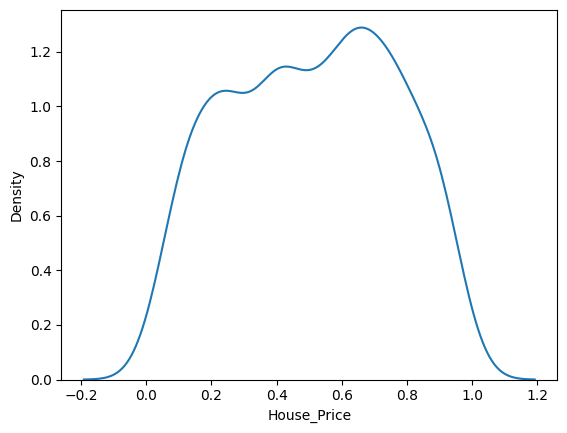

In [57]:
sns.kdeplot(x='House_Price', data=data_scaled)

<Axes: xlabel='House_Price', ylabel='Year_Built'>

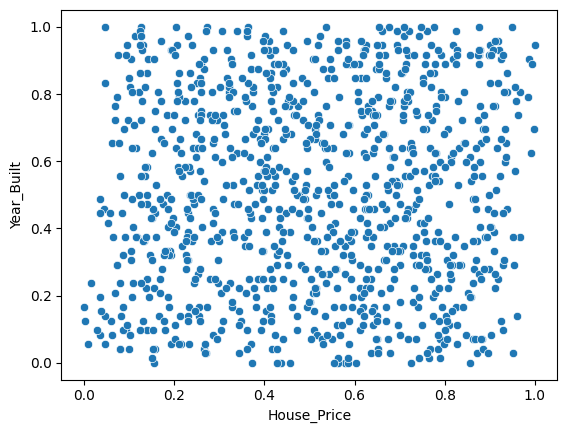

In [59]:
sns.scatterplot(x='House_Price', y='Year_Built', data=data_scaled)

# train and test dataset

In [60]:
X = data_scaled.drop('House_Price', axis=1)
X

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,0.19,0.25,0.00,0.43,0.02,0.00,0.44
1,0.84,0.50,1.00,0.92,0.95,0.50,0.56
2,0.69,0.00,0.50,0.92,0.70,0.00,0.89
3,0.10,0.00,0.50,0.38,0.50,0.50,0.78
4,0.98,0.25,0.00,0.60,0.94,0.00,0.78
...,...,...,...,...,...,...,...
995,0.61,0.75,0.00,0.39,0.37,1.00,1.00
996,0.60,0.00,0.50,0.68,0.55,0.50,1.00
997,0.47,0.75,0.50,0.17,0.79,0.00,0.11
998,0.94,1.00,0.50,0.00,0.32,0.00,0.67


In [61]:
y = data_scaled['House_Price']
y

0     0.15
1     0.88
2     0.67
3     0.12
4     0.93
      ... 
995   0.59
996   0.57
997   0.46
998   0.86
999   0.63
Name: House_Price, Length: 1000, dtype: float64

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Regression algorithm

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [79]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'SVM': SVR(),
}

In [80]:
import joblib
scores = []

In [81]:
# train, predict, check accuracy using metrics
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    ms = mean_squared_error(y_test,y_pred)
    ma = mean_absolute_error(y_test,y_pred)
    rs = r2_score(y_test,y_pred)
    scores.append(rs)
    joblib.dump(model,f"{name}.pkl")
    print(name)
    print("Mean squared error: ", ms)
    print("Mean absolute error: ", ma)
    print("R2 Score: ",rs)
    print("-------------")

LinearRegression
Mean squared error:  0.00010212604292137952
Mean absolute error:  0.008202389842096702
R2 Score:  0.9984263636823413
-------------
DecisionTreeRegressor
Mean squared error:  0.0010180740810737832
Mean absolute error:  0.02476963280045612
R2 Score:  0.9843127345169141
-------------
RandomForestRegressor
Mean squared error:  0.0004210820215214041
Mean absolute error:  0.01668269848766398
R2 Score:  0.9935116455820252
-------------
KNeighborsRegressor
Mean squared error:  0.01132804295480995
Mean absolute error:  0.08605864473161001
R2 Score:  0.8254488346776557
-------------
SVM
Mean squared error:  0.003293523671852142
Mean absolute error:  0.04371635017134055
R2 Score:  0.9492508637871631
-------------


In [82]:
scores

[0.9984263636823413,
 0.9843127345169141,
 0.9935116455820252,
 0.8254488346776557,
 0.9492508637871631]

In [85]:
model_name = list(models.keys())
model_name

['LinearRegression',
 'DecisionTreeRegressor',
 'RandomForestRegressor',
 'KNeighborsRegressor',
 'SVM']

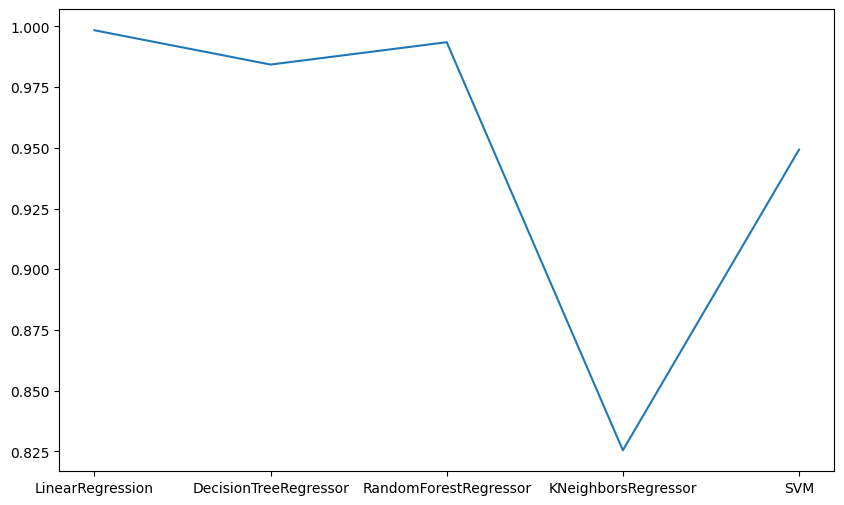

In [88]:
plt.figure(figsize=(10,6))
sns.lineplot(x=model_name,y=scores)
plt.show()

In [89]:
# LinearRegression has the highest accuracy: 99.85 %

In [90]:
# use linearRegression model and predict for other samples
lr_model = joblib.load('LinearRegression.pkl')

In [91]:
data.shape

(1000, 8)

In [99]:
# take 100 records from 'data_scaled' dataset
sample_data_scaled = data_scaled.sample(n=100)
sample_data_scaled.head(2)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
130,0.16,1.00,1.00,0.85,0.75,1.00,0.11,0.26
685,0.80,0.00,0.00,0.44,0.50,1.00,0.11,0.72


In [100]:
sample_data_scaled_pred = lr_model.predict(sample_data_scaled.drop('House_Price', axis=1))
accuracy = r2_score(sample_data_scaled.House_Price, sample_data_scaled_pred)
print("Accuracy : ", accuracy)

Accuracy :  0.9985430245285367


In [101]:
# lets take 10 samples , each sample with random 100 recods from 'data_scaled' dataset
for x in range(10):
    sample = data_scaled.sample(n=100)
    sample_pred = lr_model.predict(sample.drop('House_Price', axis=1))
    rs = r2_score(sample['House_Price'], sample_pred)
    print(f"Sample: {x}, Accuracy: {rs}")
    

Sample: 0, Accuracy: 0.9982491081421454
Sample: 1, Accuracy: 0.9982452436754041
Sample: 2, Accuracy: 0.9987059059729928
Sample: 3, Accuracy: 0.9979281763562177
Sample: 4, Accuracy: 0.9985608168034263
Sample: 5, Accuracy: 0.998275378564916
Sample: 6, Accuracy: 0.9981688333162348
Sample: 7, Accuracy: 0.9986154171073773
Sample: 8, Accuracy: 0.9989063700276716
Sample: 9, Accuracy: 0.9982505956867457
